### Install pre-requistes


In [1]:
!pip install --upgrade pip SPARQLWrapper pandas matplotlib  --quiet 
import sys
!{sys.executable} -m pip uninstall -y py4cytoscape
!{sys.executable} -m pip install py4cytoscape

Found existing installation: py4cytoscape 1.13.0
Uninstalling py4cytoscape-1.13.0:
  Successfully uninstalled py4cytoscape-1.13.0
  Using cached py4cytoscape-1.13.0-py3-none-any.whl.metadata (5.1 kB)
Using cached py4cytoscape-1.13.0-py3-none-any.whl (196 kB)



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ENDPOINT_URL = "http://localhost:7200/repositories/KG-Questionnaire_NoPlatform"

PREFIXES = """\
PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ds:   <http://digistrucmed.org/questionnaire#>
"""

In [3]:
def run_query(query: str) -> pd.DataFrame:
    """Run a SPARQL SELECT query and return the results as a Pandas DataFrame."""
    sparql = SPARQLWrapper(ENDPOINT_URL)
    sparql.setReturnFormat(JSON)
    sparql.setQuery(PREFIXES + "\n" + query)
    results = sparql.query().convert()

    cols = results["head"].get("vars", [])
    rows = []
    for b in results["results"]["bindings"]:
        row = {}
        for c in cols:
            val = b.get(c, {}).get("value")
            row[c] = val
        rows.append(row)
    return pd.DataFrame(rows, columns=cols)

def short_uri(uri):
    """Return the local name of a URI (the part after the last '#' or '/')."""
    if uri is None or (isinstance(uri, float) and pd.isna(uri)):
        return uri
    uri = str(uri)
    return uri.rsplit("#", 1)[-1] if "#" in uri else uri.rsplit("/", 1)[-1]

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_colwidth", 120)


## 1. Overview: all classes, instance counts and descriptions

This query gives a quick overview of the entities in your graph: for each Questionnaire class it shows how many instances exist and, where available, the class description from the ontology.


In [ ]:
q1 = """\
SELECT ?type
       (STRAFTER(STR(?type), "#") AS ?className)
       (COUNT(DISTINCT ?entity) AS ?instances)
       (SAMPLE(?comment) AS ?description)
WHERE {
  ?entity rdf:type ?type .
  FILTER(STRSTARTS(STR(?type), STR(ds:)))
  OPTIONAL { ?type rdfs:comment ?comment . }
}
GROUP BY ?type
ORDER BY DESC(?instances)
"""
df1 = run_query(q1)
df1["instances"] = pd.to_numeric(df1["instances"], errors="coerce")
df1[["className", "instances"]]


,className,instances,description
0,Answered,3154,None
1,Answer,310,None
2,User,273,None
3,Nominal,151,None
4,Ordinal,115,None
5,Question,42,None
6,NullAnswer,42,None
7,Questionnaire,3,None
8,Textual,2,None
9,ModuleEvaluation,1,None


## 2. Distribution of instances per class

Counts how many instances there are of each Questionnaire class, and what share of all instances each class represents.


In [5]:
q2 = """\
SELECT ?type (STRAFTER(STR(?type), "#") AS ?className) (COUNT(?instance) AS ?count)
WHERE {
  ?instance rdf:type ?type .
  FILTER(STRSTARTS(STR(?type), STR(ds:)))
}
GROUP BY ?type
ORDER BY DESC(?count)
"""

df2 = run_query(q2)
df2["count"] = pd.to_numeric(df2["count"], errors="coerce")
df2["percentage"] = (df2["count"] / df2["count"].sum() * 100).round(2)
df2[["className", "count", "percentage"]]


,className,count,percentage
0,Answered,3154,77.00
1,Answer,310,7.57
2,User,273,6.67
3,Nominal,151,3.69
4,Ordinal,115,2.81
5,Question,42,1.03
6,NullAnswer,42,1.03
7,Questionnaire,3,0.07
8,Textual,2,0.05
9,ModuleEvaluation,1,0.02


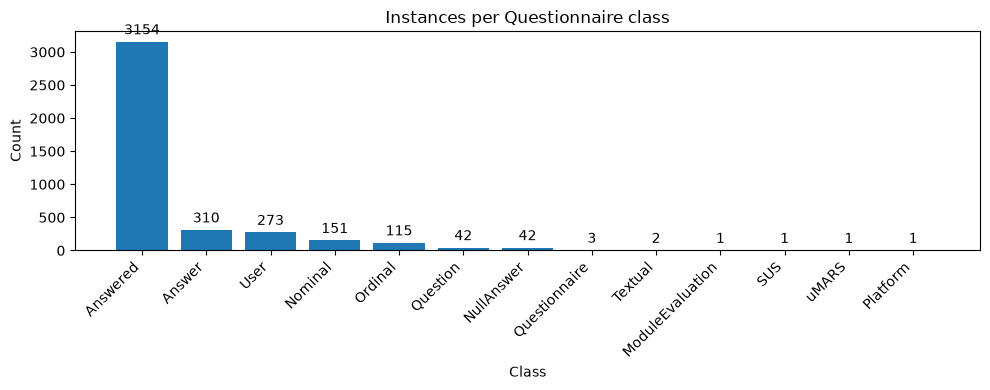

In [6]:
if not df2.empty:
    df2_plot = df2.dropna(subset=["count"]).sort_values("count", ascending=False)
    plt.figure(figsize=(10, 4))
    plt.xticks(rotation=45, ha="right")
    plt.title("Instances per Questionnaire class")
    plt.ylabel("Count")
    plt.xlabel("Class")
    bars = plt.bar(df2_plot["className"], df2_plot["count"])
    plt.bar_label(bars, padding=3)
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot for query 2.")


## 3. Answers per user and questionnaire

Lists the number of answers each user submitted in each questionnaire, then summarizes response volume per user and per questionnaire.


In [7]:
q3 = """\
SELECT ?user ?questionnarie (COUNT(?instance) AS ?count)
WHERE {
  ?instance rdf:type ds:Answered ;
    ds:answeredByUser ?user ;
    ds:answeredInQuestionnaire ?questionnarie .
}
GROUP BY ?user ?questionnarie
ORDER BY DESC(?count)
"""

df3 = run_query(q3)
df3["count"] = pd.to_numeric(df3["count"], errors="coerce")
df3["user"] = df3["user"].apply(short_uri)
df3["questionnarie"] = df3["questionnarie"].apply(short_uri)
df3.head(20)


,user,questionnarie,count
0,50,uMARS,24
1,55,uMARS,24
2,81,uMARS,24
3,100,uMARS,24
4,127,uMARS,24
5,139,uMARS,24
6,141,uMARS,24
7,155,uMARS,24
8,170,uMARS,24
9,177,uMARS,24


questionnarie,ME1,SUS,uMARS
user,,,
100,0.0,0.0,24.0
103,8.0,0.0,0.0
105,8.0,0.0,0.0
106,8.0,0.0,0.0
107,8.0,0.0,0.0
113,8.0,0.0,0.0
115,0.0,10.0,0.0
117,8.0,0.0,0.0
118,8.0,0.0,0.0


,respondents,total_answers,avg_answers_per_user
questionnarie,,,
ME1,166,1328,8.0
uMARS,54,1296,24.0
SUS,53,530,10.0


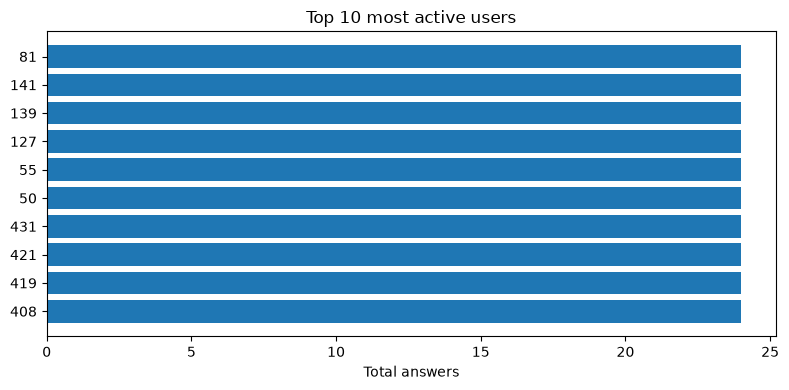

In [8]:
# Pivot: answers per user (rows) x questionnaire (columns)
pivot3 = df3.pivot_table(
    index="user", columns="questionnarie", values="count", fill_value=0
)
display(pivot3.head(20))

# Summary per questionnaire: respondents, total and average answers per user
summary3 = (
    df3.groupby("questionnarie")
    .agg(
        respondents=("user", "nunique"),
        total_answers=("count", "sum"),
        avg_answers_per_user=("count", "mean"),
    )
    .round(2)
    .sort_values("total_answers", ascending=False)
)
display(summary3)

# Top 10 most active users overall
top_users = df3.groupby("user")["count"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 4))
plt.barh(top_users.index[::-1], top_users.values[::-1])
plt.xlabel("Total answers")
plt.title("Top 10 most active users")
plt.tight_layout()
plt.show()


## 4.Network Degree Centrality of Questionnaire Entities
Using predicate edges.

Number of nodes: 3795
Number of edges: 16474


,label,type,centrality,node
3708,1,Platform,0.831313,http://digistrucmed.org/questionnaire#1
1,ME1,"ModuleEvaluation, Questionnaire",0.352135,http://digistrucmed.org/questionnaire#ME1
21,uMARS,"Questionnaire, uMARS",0.347918,http://digistrucmed.org/questionnaire#uMARS
10,SUS,"Questionnaire, SUS",0.142330,http://digistrucmed.org/questionnaire#SUS
5,M006_01,Question,0.047443,http://digistrucmed.org/questionnaire#M006_01
3,M004_01,Question,0.047443,http://digistrucmed.org/questionnaire#M004_01
2,M003_01,Question,0.047443,http://digistrucmed.org/questionnaire#M003_01
0,M002_01,Question,0.047443,http://digistrucmed.org/questionnaire#M002_01
8,M010_01,Question,0.047443,http://digistrucmed.org/questionnaire#M010_01
4,M005,Question,0.045598,http://digistrucmed.org/questionnaire#M005


Average number of neighbors (overall): 8.681949934123848


,type_label,nodes,avg_neighbors,max_neighbors
6,Platform,1,3154.000000,3154
2,ModuleEvaluation,1,1336.000000,1336
12,uMARS,1,1320.000000,1320
8,Questionnaire,3,1065.333333,1336
9,SUS,1,540.000000,540
7,Question,42,84.476190,180
10,Textual,2,82.000000,101
4,NullAnswer,42,14.928571,107
5,Ordinal,115,12.956522,68
0,Answer,310,12.174194,107


Average shortest path length (largest component): 2.332608799831646


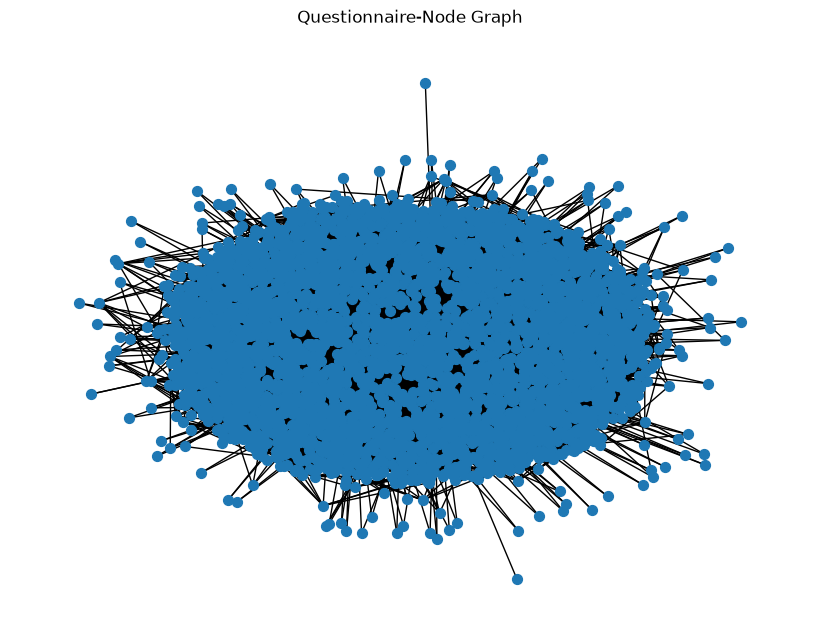

In [9]:
# Build a Questionnaire relations graph
q_edges = """
SELECT DISTINCT ?s ?p ?o
WHERE {
  ?s ?p ?o .
  FILTER(isIRI(?s) && isIRI(?o))
  FILTER(STRSTARTS(STR(?p), "http://digistrucmed.org/questionnaire#"))
}
"""

q_node_types = """
SELECT DISTINCT ?node ?type
WHERE {
  ?node rdf:type ?type .
  FILTER(STRSTARTS(STR(?type), "http://digistrucmed.org/questionnaire#"))
}
"""

# Run queries
df_edges = run_query(q_edges)
df_node_types = run_query(q_node_types)

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

def short_uri(x):
    x = str(x)
    return x.rsplit("#", 1)[-1] if "#" in x else x.rsplit("/", 1)[-1]

G = nx.Graph()
for _, r in df_edges.iterrows():
    G.add_edge(r["s"], r["o"], predicate=short_uri(r["p"]))

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

# Degree centrality
deg_centrality = nx.degree_centrality(G)

type_labels = df_node_types.copy()
type_labels["type_label"] = type_labels["type"].map(short_uri)

node_type_map = (
    type_labels.groupby("node")["type_label"]
    .apply(lambda values: ", ".join(sorted(set(values))))
    .to_dict()
)

df_deg = (
    pd.DataFrame(deg_centrality.items(), columns=["node", "centrality"])
      .assign(
          label=lambda d: d["node"].map(short_uri),
          type=lambda d: d["node"].map(node_type_map).fillna("Unknown")
      )
      .sort_values("centrality", ascending=False)
)

display(df_deg[["label", "type", "centrality", "node"]].head(20))

# Average number of neighbors
degrees = dict(G.degree())
avg_neighbors = sum(degrees.values()) / len(degrees) if degrees else 0
print("Average number of neighbors (overall):", avg_neighbors)

# Average neighbors by real questionnaire class
degree_df = pd.DataFrame(degrees.items(), columns=["node", "degree"])

typed_degree_df = type_labels.merge(degree_df, on="node", how="inner")

avg_neighbors_by_type = (
    typed_degree_df.groupby("type_label", as_index=False)
    .agg(
        nodes=("node", "nunique"),
        avg_neighbors=("degree", "mean"),
        max_neighbors=("degree", "max")
    )
    .sort_values("avg_neighbors", ascending=False)
)

display(avg_neighbors_by_type)

# Additional global metrics
if G.number_of_nodes() > 0:
    try:
        if nx.is_connected(G):
            asp = nx.average_shortest_path_length(G)
        else:
            largest_cc = max(nx.connected_components(G), key=len)
            H = G.subgraph(largest_cc).copy()
            asp = nx.average_shortest_path_length(H)

        print("Average shortest path length (largest component):", asp)
    except Exception as e:
        print("Could not compute average shortest path length:", e)

# Network Visualization
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=0)

nx.draw(G, pos, with_labels=False, node_size=50)
plt.title("Questionnaire-Node Graph")
plt.show()

## 5. Centrality analysis in Cytoscape (py4cytoscape)

This sends the questionnaire relation graph to a running Cytoscape desktop session, runs Cytoscape's NetworkAnalyzer, and retrieves the node centrality measures. Start Cytoscape before running this cell.

In [10]:
import py4cytoscape as p4c

# Cytoscape must be open locally (Apps -> CyREST is included by default).
try:
    p4c.cytoscape_ping()
except Exception as exc:
    raise ConnectionError(
        'Cytoscape is not reachable. Open Cytoscape, wait for it to finish starting, then rerun this cell.'
    ) from exc

# Reuse df_edges created in Section 4. Cytoscape expects id/source/target columns.
nodes_cy = pd.DataFrame({'id': sorted(G.nodes())})
nodes_cy['label'] = nodes_cy['id'].map(lambda uri: str(uri).rsplit('#', 1)[-1])
edges_cy = df_edges[['s', 'o', 'p']].rename(
    columns={'s': 'source', 'o': 'target', 'p': 'predicate'}
)
edges_cy['interaction'] = edges_cy['predicate'].map(
    lambda uri: str(uri).rsplit('#', 1)[-1]
)

network_suid = p4c.create_network_from_data_frames(
    nodes=nodes_cy, edges=edges_cy,
    title='Questionnaire relation graph - centrality',
    collection='Questionnaire analysis'
)

# The graph was built as undirected in NetworkX, so analyse it as undirected here too.
p4c.set_current_network(network_suid)
p4c.analyze_network(directed=False)

# Retrieve the centrality results written by Cytoscape NetworkAnalyzer.
node_table = p4c.get_table_columns(table='node', network=network_suid)
centrality_metrics = [
    metric for metric in [
        'Degree', 'BetweennessCentrality', 'ClosenessCentrality',
        'Radiality', 'Stress', 'ClusteringCoefficient'
    ] if metric in node_table.columns
]

centrality_df = (
    node_table[['name'] + centrality_metrics]
    .rename(columns={'name': 'node'})
    .sort_values(
        by='BetweennessCentrality' if 'BetweennessCentrality' in centrality_metrics else 'Degree',
        ascending=False
    )
    .reset_index(drop=True)
)

display(centrality_df.head(20))
centrality_df.to_csv('questionnaire_cytoscape_centrality.csv', index=False)
print(f'Created Cytoscape network {network_suid} and saved centrality results for {len(centrality_df)} nodes.')

You are connected to Cytoscape!
Applying default style...
Applying preferred layout


,node,Degree,BetweennessCentrality,ClosenessCentrality,Radiality,Stress,ClusteringCoefficient
0,http://digistrucmed.org/questionnaire#1,3154,0.778933,0.839381,0.999939,224100736,0.000000
1,http://digistrucmed.org/questionnaire#uMARS,1320,0.087403,0.427445,0.999575,12089610,0.001489
2,http://digistrucmed.org/questionnaire#ME1,1336,0.081669,0.428943,0.999578,13358724,0.001489
3,http://digistrucmed.org/questionnaire#SUS,540,0.015009,0.355410,0.999425,1948696,0.003642
4,http://digistrucmed.org/questionnaire#nan,91,0.007841,0.365405,0.999449,892040,0.000000
5,http://digistrucmed.org/questionnaire#M006_01,180,0.002921,0.387222,0.999498,3034054,0.020608
6,http://digistrucmed.org/questionnaire#M003_01,180,0.002689,0.386118,0.999496,2938006,0.020608
7,http://digistrucmed.org/questionnaire#M004_01,180,0.002683,0.386118,0.999496,2937970,0.020608
8,http://digistrucmed.org/questionnaire#M002_01,180,0.002682,0.386118,0.999496,2937970,0.020608
9,http://digistrucmed.org/questionnaire#M010_01,180,0.002170,0.386118,0.999496,1944822,0.020608


Created Cytoscape network 128 and saved centrality results for 3795 nodes.


,question_short,questionText,responseCode,answer,frequency,percentage
0,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,10,sehr [10],61,36.75
1,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,8,Skalenwert 8,44,26.51
2,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,9,Skalenwert 9,29,17.47
3,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,7,Skalenwert 7,14,8.43
4,M002_01,wie Hilfreich: Wie hilfreich fanden Sie die Inhalte des Moduls?,5,Skalenwert 5,5,3.01
...,...,...,...,...,...,...
95,SU01_07,"System Usability Scale (SUS): Ich k�nnte mir vorstellen, dass die meisten Personen sehr schnell lernen w�rden mit di...",NaN,No recorded response,8,15.09
96,SU01_07,"System Usability Scale (SUS): Ich k�nnte mir vorstellen, dass die meisten Personen sehr schnell lernen w�rden mit di...",2,Likert response 2,4,7.55
97,SU01_08,System Usability Scale (SUS): Ich fand die Lernplattform sehr umst�ndlich zu nutzen. (umgepolt),5,trifft gar nicht zu,24,45.28
98,SU01_08,System Usability Scale (SUS): Ich fand die Lernplattform sehr umst�ndlich zu nutzen. (umgepolt),4,Likert response 4,13,24.53


,responseCode,answer,frequency,percentage
34,10,sehr gut [10],55,33.13
35,8,Skalenwert 8,46,27.71
36,9,Skalenwert 9,34,20.48
37,7,Skalenwert 7,12,7.23
38,6,Skalenwert 6,8,4.82
39,5,Skalenwert 5,4,2.41
40,NaN,No recorded response,4,2.41
41,1,sehr schlecht [1],1,0.60
42,3,Skalenwert 3,1,0.60
43,4,Skalenwert 4,1,0.60


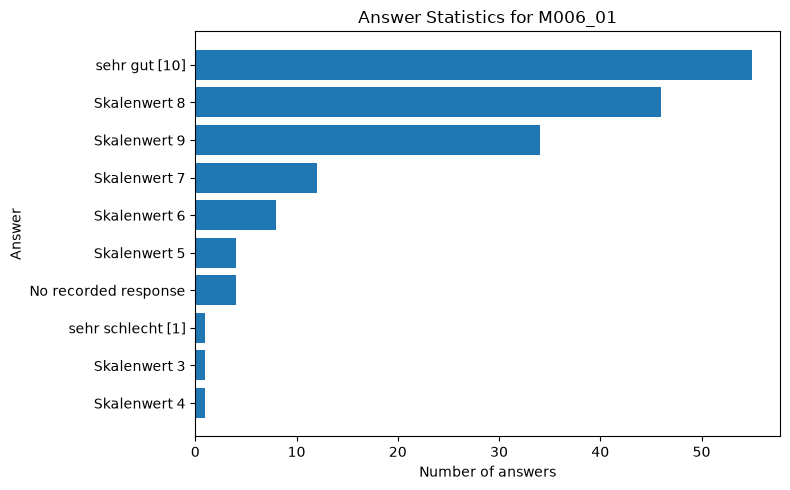

,responseCode,answer,frequency,percentage
100,NaN,No recorded response,543,17.22
97,8,Skalenwert 8,185,5.87
98,9,Skalenwert 9,185,5.87
99,TEXT,Textual response,160,5.07
70,4,Likert response 4,134,4.25
92,5,trifft gar nicht zu,114,3.61
18,10,sehr gut [10],114,3.61
53,4,4,112,3.55
10,1,Text,88,2.79
50,3,Likert response 3,86,2.73


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Helper
def short_uri(x):
    if pd.isna(x):
        return x
    x = str(x)
    return x.split("#")[-1] if "#" in x else x

# ------------------------------------------------------------
# Simple answer statistics per question
# ------------------------------------------------------------

q_answer_stats = """
SELECT
    ?question
    ?questionText
    ?responseCode
    ?responseLabel
    (COUNT(DISTINCT ?answered) AS ?frequency)
WHERE {
    ?answered ds:hasQuestion ?question ;
              ds:hasAnswer ?answer .

    OPTIONAL { ?question ds:QuestionDescription ?questionText . }
    OPTIONAL { ?answer ds:ResponseCode ?responseCode . }
    OPTIONAL { ?answer ds:ResponseLabel ?responseLabel . }
}
GROUP BY ?question ?questionText ?responseCode ?responseLabel
ORDER BY ?question DESC(?frequency)
"""

df = run_query(q_answer_stats)

df["frequency"] = df["frequency"].astype(int)
df["question_short"] = df["question"].apply(short_uri)

df["answer"] = df["responseLabel"].fillna(df["responseCode"])
df["total_per_question"] = df.groupby("question")["frequency"].transform("sum")

df["percentage"] = (
    df["frequency"] / df["total_per_question"] * 100
).round(2)

df = df.sort_values(
    ["question_short", "frequency"],
    ascending=[True, False]
)

display(df[[
    "question_short",
    "questionText",
    "responseCode",
    "answer",
    "frequency",
    "percentage"
]].head(100))

# For one specific question, show the distribution of answers
question_id = "M006_01"   # change this

one_question = df[df["question_short"] == question_id]

display(one_question[[
    "responseCode",
    "answer",
    "frequency",
    "percentage"
]])

plt.figure(figsize=(8, 5))
plt.barh(one_question["answer"], one_question["frequency"])
plt.gca().invert_yaxis()
plt.xlabel("Number of answers")
plt.ylabel("Answer")
plt.title(f"Answer Statistics for {question_id}")
plt.tight_layout()
plt.show()

#For an overall view, show the most common answers across all questions
overall = (
    df.groupby(["responseCode", "answer"], dropna=False)["frequency"]
    .sum()
    .reset_index()
    .sort_values("frequency", ascending=False)
)

overall["percentage"] = (
    overall["frequency"] / overall["frequency"].sum() * 100
).round(2)

display(overall.head(30))